In [152]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

In [153]:
df = pd.read_csv('customer_churn.csv')
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [154]:
df_copy = df.drop(columns=['Names', 'Company'])
df_copy['Onboard_date'] = pd.to_datetime(df_copy['Onboard_date']).dt.year
df_copy['Location'] = df_copy['Location'].str.extract(r'\s([A-Z]{2})\s+\d{5}')

X = df_copy.copy().drop(columns=['Churn'])
y = df_copy.copy()['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['Age', 'Total_Purchase', 'Years', 'Num_Sites', 'Onboard_date']),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Location']) 
    ],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

w = np.zeros(shape=(X_train.shape[1], 1))
b = 0.0

y_train = y_train.to_numpy().reshape(-1, 1)
y_test = y_test.to_numpy().reshape(-1, 1)

In [155]:
alpha = 0.1
epoch = 100000
lambda_ = 0.01
while(epoch > 0):
    z = X_train.dot(w) + b
    y_hat = 1 / (1 + np.exp(-z))
    base_loss = -np.mean(y_train * np.log(y_hat) + (1 - y_train) * np.log(1 - y_hat))
    loss = base_loss + (lambda_ / 2) * np.sum(w**2)
    print('J:',loss)

    base_dw = X_train.T.dot(y_hat - y_train) / X_train.shape[0]
    dw = base_dw + lambda_ * w
    db = np.mean(y_hat - y_train)

    w = w - alpha * dw
    b = b - alpha * db

    epoch -= 1
    if(epoch % 10000 == 0):
        alpha *= 0.9

J: 0.6931471805599453
J: 0.6755016385405509
J: 0.6589188085826952
J: 0.6433314335273634
J: 0.6286751819517157
J: 0.6148888634859663
J: 0.601914556208525
J: 0.5896976599550292
J: 0.5781868889752713
J: 0.567334216415408
J: 0.5570947818095794
J: 0.5474267713105735
J: 0.5382912789047026
J: 0.5296521554322579
J: 0.5214758509286709
J: 0.5137312546431934
J: 0.5063895360926501
J: 0.49942398966551393
J: 0.4928098845958535
J: 0.48652432156270264
J: 0.4805460967212129
J: 0.4748555736205454
J: 0.46943456319369936
J: 0.46426621180174027
J: 0.4593348971663655
J: 0.4546261319194399
J: 0.4501264744268241
J: 0.4458234464988804
J: 0.4417054575752657
J: 0.43776173496199133
J: 0.433982259700269
J: 0.43035770765623144
J: 0.4268793954357621
J: 0.4235392307475019
J: 0.42032966685819856
J: 0.4172436608068215
J: 0.4142746350665058
J: 0.41141644236581576
J: 0.4086633334026337
J: 0.40600992720489504
J: 0.40345118391223794
J: 0.40098237977129725
J: 0.39859908415481504
J: 0.39629713843094083
J: 0.39407263652408275

In [156]:
z = X_test.dot(w) + b
y_proba = 1 / (1 + np.exp(-z))
y_pred = np.where(y_proba > 0.25, 1, 0)

In [157]:
print('Accuracy:\t', accuracy_score(y_test, y_pred))
print('Precision:\t', precision_score(y_test, y_pred))
print('Recall:\t\t', recall_score(y_test, y_pred))
print('F1 score:\t', f1_score(y_test, y_pred))

Accuracy:	 0.8777777777777778
Precision:	 0.6052631578947368
Recall:		 0.7666666666666667
F1 score:	 0.6764705882352942


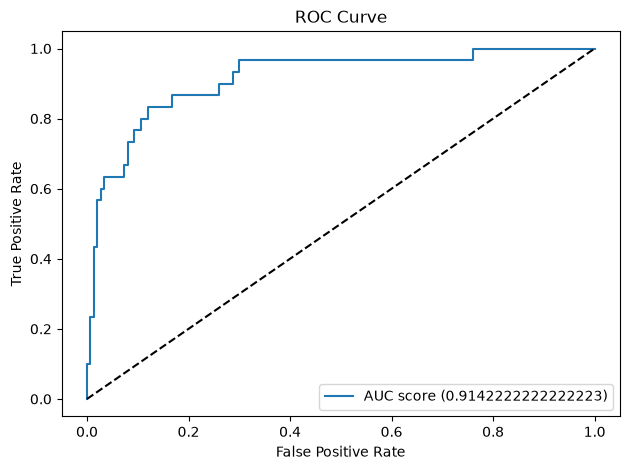

In [158]:
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC score ({roc_auc_score(y_test, y_proba)})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()